<a href="https://colab.research.google.com/github/kursatkara/MAE_5020_Spring_2026/blob/master/04_05_over_determined_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Overdetermined Systems: Satellite Orbit Tracking

In aerospace operations, estimating the state of a vehicle often involves processing data from redundant, noisy sensors.
This forms an **overdetermined system** $Ax = b$ where:
*   $x$ is the unknown state vector (e.g., $m=100$ orbital parameters or positions representing the satellite's exact track).
*   $b$ are the measured outputs (e.g., $n=500$ distance readings from various ground radar stations).
*   $A$ is the $n \times m$ observation matrix mapping the orbital track to the expected radar distances.

Because $n > m$ (500 equations > 100 unknowns), and because real radar measurements $b$ contain thermal noise and atmospheric distortion, **no single vector $x$ can perfectly satisfy all 500 equations**.

We must find the "best fit" approximation. The standard approach is the **Least Squares (L2) Solution**, which minimizes the sum of the squared measurement residuals:
$$ \text{Minimize } ||Ax - b||_2^2 $$

This is analytically solved using the Normal Equations: $x = (A^T A)^{-1} A^T b$. In Python, `numpy.linalg.pinv(A)` computes this robustly.

The code from the textbook [1] was extensively refactored for clarity and framed within this aerospace context to demonstrate $L_2$ regression recovering a true signal from heavy noise.

[1] https://github.com/kursatkara/databook_python/blob/master/CH04/CH04_SEC03_1_OverUnderDetermined.ipynb

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import rcParams

# Plotting aesthetics
rcParams.update({'font.size': 14})
rcParams['axes.grid'] = True
rcParams['figure.figsize'] = [10, 8]

In [22]:
# Number of radar measurements (equations)
n_measurements = 500
# Number of unknown orbital parameters
m_parameters = 100

# Seed for reproducible synthetic data
np.random.seed(123)

# 1. Generate the "True" Orbital State (The answer we want our math to find)
x_true = np.random.randn(m_parameters)

# 2. Generate the physical Observation Matrix (How parameters map to radar)
A_radar = np.random.randn(n_measurements, m_parameters)

# 3. Simulate perfect, noiseless radar readings
b_perfect = A_radar @ x_true

# 4. Add sensor noise to simulate reality (Gaussian noise with mean 0, std 0.5)
#noise = 4.5 * np.random.randn(n_measurements) + 6.5
noise = 0.5 * np.random.randn(n_measurements) + 0.0
b_noisy = b_perfect + noise

print(f"System generated: {n_measurements} noisy measurements for {m_parameters} unknown parameters.")

System generated: 500 noisy measurements for 100 unknown parameters.


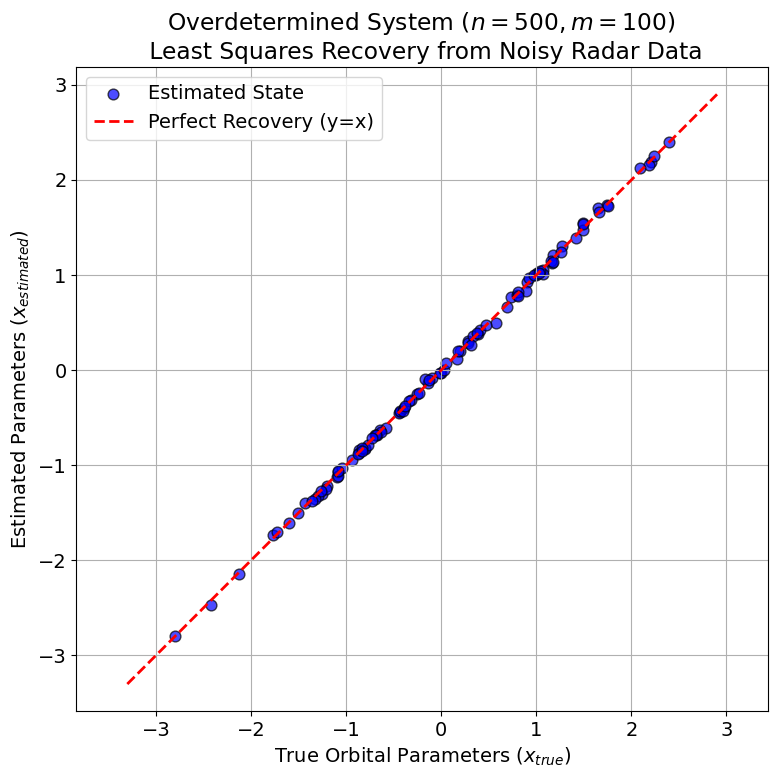

Mean Squared Error of Estimation: 0.0007


In [23]:
################################################################################
# Approach: Least Squares (L2) Regression using Pseudo-Inverse
# Objective: Minimize ||A*x - b_noisy||_2^2
################################################################################

# We use the noisy measurements, just like a real ground station would.
# pinv(A) essentially calculates (A^T * A)^(-1) * A^T
x_estimated = np.linalg.pinv(A_radar) @ b_noisy

# Let's see how well we recovered the True state!
# A perfect estimation would mean x_estimated == x_true everywhere.

plt.figure(figsize=(8, 8))

# Scatter plot: True Parameters vs Estimated Parameters
plt.scatter(x_true, x_estimated, color='blue', alpha=0.7, edgecolors='k', s=60, label='Estimated State')

# The ideal 1:1 line where Estimate perfectly matches Truth
limits = [np.min([x_true, x_estimated])-0.5, np.max([x_true, x_estimated])+0.5]
plt.plot(limits, limits, 'r--', linewidth=2, label='Perfect Recovery (y=x)')

plt.xlim(limits)
plt.ylim(limits)
plt.xlabel('True Orbital Parameters ($x_{true}$)')
plt.ylabel('Estimated Parameters ($x_{estimated}$)')
plt.title(f'Overdetermined System ($n={n_measurements}, m={m_parameters}$) \n Least Squares Recovery from Noisy Radar Data')
plt.legend()
plt.axis('equal') # Keep the aspect ratio square so the 1:1 line is exactly 45 degrees
plt.tight_layout()
plt.show()

# Calculate the mean squared error of our estimation
mse = np.mean((x_true - x_estimated)**2)
print(f"Mean Squared Error of Estimation: {mse:.4f}")
#print("Notice how tightly the scatter points hug the red line despite heavy noise in the raw data!")

### Challenge Problem: Weighted Least Squares (WLS)
In satellite tracking, not all ground stations are equal. A station near the zenith has high fidelity (low noise), while a station on the horizon has high atmospheric distortion (high noise). Instead of standard Least Squares, we should use **Weighted Least Squares**, which penalizes equations based on their known measurement variance $W$: $x = (A^T W A)^{-1} A^T W b$. Your challenge: Implement WLS assuming half the radar stations have 5x higher noise variance than the others.

In [18]:
# YOUR CODE HERE
# 1. Create a diagonal Weight matrix W (size 500x500)
# 2. Set the weights of the first 250 stations to 1.0 (low noise), and the last 250 to 0.2 (high noise)
# 3. Solve the WLS normal equations: x_wls = inv(A.T @ W @ A) @ A.T @ W @ b_noisy
# 4. Calculate the MSE of x_wls compared to x_true, and compare it to the standard L2 MSE
# ...

<details>
<summary><b>Click to Reveal Solution</b></summary>

```python
# 1 & 2. Create the Weight matrix
weights = np.ones(n_measurements)
# Simulate that the last 250 stations are 5x noisier, so we give them 1/5th the weight
weights[250:] = 0.2
W = np.diag(weights)

# 3. Solve Weighted Least Squares
# Normal equations: (A^T * W * A) * x = A^T * W * b
# x = inv(A^T * W * A) * (A^T * W * b)
A_T_W_A = A_radar.T @ W @ A_radar
A_T_W_b = A_radar.T @ W @ b_noisy
x_wls = np.linalg.inv(A_T_W_A) @ A_T_W_b

# 4. Compare MSEs
mse_standard = np.mean((x_true - x_estimated)**2)
mse_wls = np.mean((x_true - x_wls)**2)

print(f"Standard L2 MSE: {mse_standard:.4f}")
print(f"Weighted L2 MSE: {mse_wls:.4f}")
print("WLS successfully reduces error by down-weighting the noisy sensors!")
```
</details>